In [2]:
import sys

import pandas as pd
from pathlib import Path
from dataclasses import asdict
from pprint import pprint

sys.path.append(str(Path.cwd().parent))

from src.data_loader import ParquetDataLoader

from src.features.fdr_weights import FDRWeightComputer
from src.features.peak_features import PeakFeatureComputer
from src.features.spectrum_features import SpectrumFeatureComputer
from src.processing.spectrum_processor import SpectrumProcessor
from src.config import load_config, load_training_config
from src.splitting.splitter import GroupedSpectrumSplitter, SplitConfig
#from src.model.mlp import MLPConfig, MLPPeakClassifier
from src.training.train_mlp import train_mlp

from src.model.mlp import MLPPeakClassifier



In [2]:
UNIQUE_PATH = "../data/combined_unique.parquet"
DUPLIC_PATH = "../data/duplicates.parquet"

In [3]:
UNIQUE_LOADER = ParquetDataLoader(UNIQUE_PATH)
UNIQUE_DF = UNIQUE_LOADER.load()
print(UNIQUE_LOADER.counts())

{'rows': 33680, 'columns': 10, 'duplicate_rows': 5219}


In [4]:
UNIQUE_DF["mz_arr"][0][UNIQUE_DF["annotation_mask"][0]]

array([ 175.11905,  217.08197,  218.14998,  219.07985,  284.10544,
        302.1168 ,  320.12766,  341.14627,  346.12457,  349.19092,
        353.18915,  413.1483 ,  431.1599 ,  432.16214,  434.2183 ,
        435.2219 ,  449.16974,  457.15588,  475.1672 ,  476.17035,
        486.24908,  514.8016 ,  515.303  ,  521.2501 ,  522.25336,
        541.20844,  558.31573,  558.81714,  559.21893,  559.3175 ,
        560.2019 ,  577.2303 ,  592.28723,  593.29126,  594.2905 ,
        600.29224,  628.274  ,  631.31903,  638.2312 ,  639.2333 ,
        656.3755 ,  656.8779 ,  671.2359 ,  688.2611 ,  689.26434,
        705.3716 ,  706.2714 ,  706.37494,  707.2744 ,  714.3353 ,
        741.35913,  804.4427 ,  816.31903,  818.4559 ,  819.46045,
        820.4623 ,  824.39185,  834.3315 ,  850.3119 ,  851.3947 ,
        852.3949 ,  856.1396 ,  872.3777 ,  931.5407 ,  932.5465 ,
        945.3623 ,  962.3886 ,  963.39154,  972.443  ,  995.0712 ,
       1028.5933 , 1029.5967 , 1030.5981 , 1090.4465 , 1115.62

In [5]:
UNIQUE_LOADER.preview()

,SearchID,PeakListFileName,scan,mz_arr,int_arr,Charge,exp m/z,annotation_mask,fdr,ScanId
0,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IW...,55103,"[159.09174, 169.1333, 171.0764, 175.11905, 183...","[718.6142, 385.75302, 360.7595, 508.82907, 461...",5,1228.597986,"[False, False, False, True, False, False, Fals...",0.0,49680
1,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_05...,37075,"[169.13365, 170.13696, 173.12848, 197.12843, 2...","[55218.297, 4290.3174, 4682.228, 8763.272, 594...",4,791.159573,"[True, True, False, False, False, False, False...",0.0,33520
2,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_99...,99952,"[154.04985, 157.13344, 169.13353, 171.07663, 1...","[1765.962, 1713.2745, 3622.377, 2485.4277, 257...",6,1023.997795,"[False, False, False, False, True, False, Fals...",0.0,92218
3,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IW...,31686,"[169.09734, 169.13359, 170.13675, 173.12851, 1...","[17889.098, 397635.06, 29883.363, 34964.855, 5...",4,787.160779,"[False, True, True, False, False, False, False...",0.0,27526
4,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_99...,37365,"[152.10715, 175.11894, 183.11316, 185.0921, 18...","[4770.7573, 13369.417, 8131.486, 7109.109, 408...",7,623.470602,"[False, True, True, False, False, False, False...",0.0,33864


(33680, 10)
['SearchID', 'PeakListFileName', 'scan', 'mz_arr', 'int_arr', 'Charge', 'exp m/z', 'annotation_mask', 'fdr', 'ScanId']


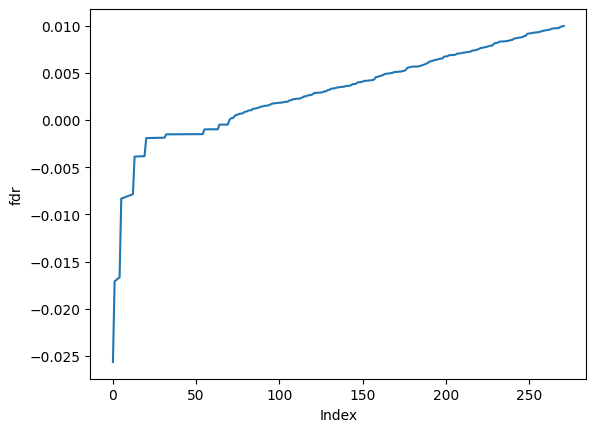

In [12]:
print(UNIQUE_DF.shape)
print(UNIQUE_DF.columns.tolist())
VALS = sorted(UNIQUE_DF["fdr"].dropna().unique())

plt.plot(VALS)
plt.xlabel("Index")
plt.ylabel("fdr")
plt.show()

In [20]:
CONFIG_PATH = Path.cwd().parent / "configs" / "config.yml"
APP_CONFIG = load_config(CONFIG_PATH)
APP_CONFIG

AppConfig(peak_features=PeakFeatureConfig(use_log_intensity=True, use_relative_intensity=True, use_mz_over_precursor=True, use_delta_to_precursor=True, use_delta_neighbors=True, sort_by_mz=True, eps=1e-08), spectrum_features=SpectrumFeatureConfig(use_tic=True, use_num_peaks=True), fdr=FDRWeightConfig(enabled=True, clip_min=0.0, clip_max=0.01, weight_min=0.2, mode='linear'), split=SplitConfig(train_fraction=0.7, val_fraction=0.15, test_fraction=0.15, random_seed=42))

In [7]:
peak_feature_computer = PeakFeatureComputer(APP_CONFIG.peak_features)
spectrum_feature_computer = SpectrumFeatureComputer(APP_CONFIG.spectrum_features)
fdr_weight_computer = FDRWeightComputer(APP_CONFIG.fdr)

In [8]:
processor = SpectrumProcessor(
    peak_feature_computer=peak_feature_computer,
    spectrum_feature_computer=spectrum_feature_computer,
    fdr_weight_computer=fdr_weight_computer,
)

In [9]:
processed_spectra = processor.process_dataframe(UNIQUE_DF)

In [10]:
ps = processed_spectra[0]

print(ps.record)
print(ps.spectrum_features)
print(ps.fdr_weight)
print(ps.peak_features.as_matrix().shape)
print(ps.spectrum_features.as_array())

SpectrumRecord(search_id='65da8b19-e373-46cb-86c3-2d3dcd0ef656', peak_list_file_name='recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IWZPvVM.mgf', scan=55103, mz_arr=array([ 159.09174,  169.1333 ,  171.0764 ,  175.11905,  183.14935,
        189.08687,  191.08487,  195.07698,  197.12827,  203.10254,
        211.14397,  213.08684,  217.08197,  218.14998,  219.07985,
        231.09732,  240.09814,  240.17053,  241.08186,  258.10828,
        259.09244,  274.122  ,  276.10257,  284.10544,  284.16037,
        298.17593,  302.1168 ,  320.12766,  324.2278 ,  341.14627,
        344.12747,  344.68442,  346.12457,  349.19092,  352.11325,
        353.18915,  359.15643,  360.16016,  368.12097,  368.1561 ,
        369.14133,  386.16666,  387.15082,  403.165  ,  413.1483 ,
        431.1599 ,  432.16214,  434.2183 ,  435.2219 ,  447.17273,
        448.18564,  449.16974,  457.15588,  466.19638,  475.1672 ,
        476.17035,  486.24908,  488.19833,  494.29803,  496.21457,
        497.1989 ,  514.8016 ,  5

In [11]:
ps = processed_spectra[0]

print("mz shape:", ps.record.mz_arr.shape)
print("int shape:", ps.record.int_arr.shape)
print("num_peaks:", ps.record.num_peaks)
print("tic:", ps.record.tic)

if ps.record.annotation_mask is not None:
    print("mask shape:", ps.record.annotation_mask.shape)

print("peak feature matrix shape:", ps.peak_features.as_matrix().shape)
print("spectrum feature vector:", ps.spectrum_features.as_array())
print("fdr result:", ps.fdr_weight)

mz shape: (296,)
int shape: (296,)
num_peaks: 296
tic: 198005.86064720154
mask shape: (296,)
peak feature matrix shape: (296, 7)
spectrum feature vector: [5.0000000e+00 1.2285980e+03 2.9600000e+02 1.9800586e+05]
fdr result: FDRWeightResult(raw_fdr=0.0, clipped_fdr=0.0, weight=1.0)


In [12]:
for i, ps in enumerate(processed_spectra[:10]):
    assert ps.record.mz_arr.ndim == 1
    assert ps.record.int_arr.ndim == 1
    assert ps.record.mz_arr.shape[0] == ps.record.int_arr.shape[0]
    assert ps.peak_features.as_matrix().shape[0] == ps.record.num_peaks

    if ps.record.annotation_mask is not None:
        assert ps.record.annotation_mask.shape[0] == ps.record.num_peaks


In [13]:
summary = pd.DataFrame(
    [
        {
            "search_id": ps.record.search_id,
            "scan": ps.record.scan,
            "num_peaks": ps.record.num_peaks,
            "tic": ps.record.tic,
            "charge": ps.spectrum_features.charge,
            "precursor_mz": ps.spectrum_features.precursor_mz,
            "raw_fdr": ps.fdr_weight.raw_fdr,
            "clipped_fdr": ps.fdr_weight.clipped_fdr,
            "weight": ps.fdr_weight.weight,
        }
        for ps in processed_spectra[:20]
    ]
)

summary.head()

,search_id,scan,num_peaks,tic,charge,precursor_mz,raw_fdr,clipped_fdr,weight
0,65da8b19-e373-46cb-86c3-2d3dcd0ef656,55103,296,1.980059e+05,5,1228.597986,0.0,0.0,1.0
1,65da8b19-e373-46cb-86c3-2d3dcd0ef656,37075,302,9.866419e+05,4,791.159573,0.0,0.0,1.0
2,65da8b19-e373-46cb-86c3-2d3dcd0ef656,99952,304,8.729050e+05,6,1023.997795,0.0,0.0,1.0
3,65da8b19-e373-46cb-86c3-2d3dcd0ef656,31686,294,7.978128e+06,4,787.160779,0.0,0.0,1.0
4,65da8b19-e373-46cb-86c3-2d3dcd0ef656,37365,306,1.032747e+06,7,623.470602,0.0,0.0,1.0


In [20]:
UNIQUE_LOADER.preview()

,SearchID,PeakListFileName,scan,mz_arr,int_arr,Charge,exp m/z,annotation_mask,fdr,ScanId
0,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IW...,55103,"[159.09174, 169.1333, 171.0764, 175.11905, 183...","[718.6142, 385.75302, 360.7595, 508.82907, 461...",5,1228.597986,"[False, False, False, True, False, False, Fals...",0.0,49680
1,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_05...,37075,"[169.13365, 170.13696, 173.12848, 197.12843, 2...","[55218.297, 4290.3174, 4682.228, 8763.272, 594...",4,791.159573,"[True, True, False, False, False, False, False...",0.0,33520
2,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_99...,99952,"[154.04985, 157.13344, 169.13353, 171.07663, 1...","[1765.962, 1713.2745, 3622.377, 2485.4277, 257...",6,1023.997795,"[False, False, False, False, True, False, Fals...",0.0,92218
3,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IW...,31686,"[169.09734, 169.13359, 170.13675, 173.12851, 1...","[17889.098, 397635.06, 29883.363, 34964.855, 5...",4,787.160779,"[False, True, True, False, False, False, False...",0.0,27526
4,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_99_CK_pepSEC_non_enri_99...,37365,"[152.10715, 175.11894, 183.11316, 185.0921, 18...","[4770.7573, 13369.417, 8131.486, 7109.109, 408...",7,623.470602,"[False, True, True, False, False, False, False...",0.0,33864


In [14]:
ps = processed_spectra[0]

print(f"search_id: {ps.record.search_id}")
print(f"scan: {ps.record.scan}")
print(f"scan_id: {ps.record.scan_id}")
print(f"file: {ps.record.peak_list_file_name}")
print("##################")
print("Spectrum features:")
print(f"  charge       : {ps.spectrum_features.charge}")
print(f"  precursor_mz : {ps.spectrum_features.precursor_mz}")
print(f"  num_peaks    : {ps.spectrum_features.num_peaks}")
print(f"  tic          : {ps.spectrum_features.tic}")
print("##################")
print("FDR:")
print(f"  raw_fdr      : {ps.fdr_weight.raw_fdr}")
print(f"  clipped_fdr  : {ps.fdr_weight.clipped_fdr}")
print(f"  weight       : {ps.fdr_weight.weight}")
print("##################")
print("Peak feature matrix:")
peak_matrix = ps.peak_features.as_matrix()
print("shape:", peak_matrix.shape)
print(peak_matrix)

search_id: 65da8b19-e373-46cb-86c3-2d3dcd0ef656
scan: 55103
scan_id: 49680
file: recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IWZPvVM.mgf
##################
Spectrum features:
  charge       : 5
  precursor_mz : 1228.597986
  num_peaks    : 296
  tic          : 198005.86064720154
##################
FDR:
  raw_fdr      : 0.0
  clipped_fdr  : 0.0
  weight       : 1.0
##################
Peak feature matrix:
shape: (296, 7)
[[ 1.5909174e+02  6.5787153e+00  9.1087751e-02 ...  1.0695063e+03
   0.0000000e+00  1.0041565e+01]
 [ 1.6913330e+02  5.9577861e+00  4.8896022e-02 ...  1.0594647e+03
   1.0041565e+01  1.9431000e+00]
 [ 1.7107640e+02  5.8909798e+00  4.5727976e-02 ...  1.0575216e+03
   1.9431000e+00  4.0426483e+00]
 ...
 [ 1.9919507e+03  3.8635643e+00  5.9111859e-03 ... -7.6335266e+02
   3.4440918e+00  3.0274658e+00]
 [ 1.9949781e+03  3.1690521e+00  2.8880977e-03 ... -7.6638013e+02
   3.0274658e+00  3.9819336e+00]
 [ 1.9989601e+03  4.1336441e+00  7.7833659e-03 ... -7.7036206e+02
   3.981933

In [43]:
## Training testing split by PeakListFileName
# The dataset is split at the **file level** using `PeakListFileName` as the grouping key.
# 1. Collect all unique values of `PeakListFileName`.
# 2. Shuffle the unique file names using a fixed random seed.
# 3. Assign the shuffled files to:
#    - train
#    - val
#    - test
#    according to the configured fractions:
#    - train_fraction
#    - val_fraction
#    - test_fraction
# 4. Assign every spectrum to the split of its corresponding `PeakListFileName`.

# Spectra from the same file are not independent.  
# They may share:
# - instrument conditions
# - sample composition
# - acquisition-specific patterns

# So splitting by file helps prevent data leakage between training, validation, and test sets.

splitter = GroupedSpectrumSplitter(APP_CONFIG.split)
split_result = splitter.split(processed_spectra)

split_result.summary_df

,split,n_rows,n_unique_spectra,n_unique_files
0,train,22871,19002,160
1,val,4668,3829,34
2,test,6141,5598,35


In [ ]:
# print("Unique PeakListFileName:", UNIQUE_DF["PeakListFileName"].nunique())
# print("Unique SearchID:", UNIQUE_DF["SearchID"].nunique())
# print("Total rows:", len(UNIQUE_DF))
# CONFIG_PATH = Path.cwd().parent / "configs" / "config.yml"
# APP_CONFIG = load_config(CONFIG_PATH)
# APP_CONFIG
# splitter_search_id = GroupedSpectrumSplitter(APP_CONFIG.split)
# split_result_search_id = splitter_search_id.split(processed_spectra)

# split_result_search_id.summary_df

In [35]:
print(split_result.summary_df)
print(split_result.file_to_split_df.head())
print(len(split_result.train), len(split_result.val), len(split_result.test))

   split  n_rows  n_unique_spectra  n_unique_files
0  train   22871             19002             160
1    val    4668              3829              34
2   test    6141              5598              35
                                    PeakListFileName  split
0  decarry_A_251014_KKC_RW_KK14-4mMDSSO_fraction7...  train
1  recal_A_260107_B2C_FS_pepSEC5_100_pepSEC_8_rep...  train
2    L1_20250612_JPL_DS48-7_BS_DBBSO_DBCO_SCX_F8.mgf  train
3  recal_Z_251115_SEC_FS_30_ProteinSEC_4mM_DSS_rs...  train
4  recal_A_260130_BOR_FS_101_pepSEC_9_BA_02mMSDA_...  train
22871 4668 6141


In [36]:
OUTPUT_DIR = Path.cwd().parent / "data" / "splits"
splitter.write_split_parquets(split_result, OUTPUT_DIR)

In [37]:
SPLIT_DIR = Path.cwd().parent / "data" / "splits"
train_df = pd.read_parquet(SPLIT_DIR / "train.parquet")

print(train_df.shape)
train_df.head(1)

(22871, 22)


,split,SearchID,PeakListFileName,scan,ScanId,mz_arr,int_arr,Charge,exp m/z,annotation_mask,...,weight,num_peaks,tic,peak_feature_mz,peak_feature_log_intensity,peak_feature_relative_intensity,peak_feature_mz_over_precursor,peak_feature_delta_to_precursor,peak_feature_delta_prev,peak_feature_delta_next
0,train,65da8b19-e373-46cb-86c3-2d3dcd0ef656,recal_Z_260313_SEC_FS_44_CK_pepSEC_non_enri_IW...,55103,49680,"[159.09173583984375, 169.13330078125, 171.0764...","[718.6141967773438, 385.7530212402344, 360.759...",5,1228.597986,"[False, False, False, True, False, False, Fals...",...,1.0,296,198005.860647,"[159.09173583984375, 169.13330078125, 171.0764...","[6.5787153244018555, 5.9577860832214355, 5.890...","[0.09108775109052658, 0.04889602214097977, 0.0...","[0.129490464925766, 0.13766366243362427, 0.139...","[1069.50634765625, 1059.4647216796875, 1057.52...","[0.0, 10.04156494140625, 1.9430999755859375, 4...","[10.04156494140625, 1.9430999755859375, 4.0426..."


In [41]:
file_to_split = pd.read_parquet(SPLIT_DIR / "file_to_split.parquet")

print(file_to_split.shape)
print(file_to_split.head(1))

split_summary = pd.read_parquet(SPLIT_DIR / "split_summary.parquet")
print(split_summary)

(229, 2)
                                    PeakListFileName  split
0  decarry_A_251014_KKC_RW_KK14-4mMDSSO_fraction7...  train
   split  n_rows  n_unique_spectra  n_unique_files
0  train   22871             19002             160
1    val    4668              3829              34
2   test    6141              5598              35


In [16]:
train_df.columns

Index(['split', 'SearchID', 'PeakListFileName', 'scan', 'ScanId', 'mz_arr',
       'int_arr', 'Charge', 'exp m/z', 'annotation_mask', 'fdr', 'clipped_fdr',
       'weight', 'num_peaks', 'tic', 'peak_feature_mz',
       'peak_feature_log_intensity', 'peak_feature_relative_intensity',
       'peak_feature_mz_over_precursor', 'peak_feature_delta_to_precursor',
       'peak_feature_delta_prev', 'peak_feature_delta_next'],
      dtype='object')

## Split parquet columns

### Core split / identification columns

- **`split`**  
  Dataset assignment for the spectrum.  
  Possible values: `train`, `val`, `test`.

- **`SearchID`**  
  Search-level identifier from the original data table.

- **`PeakListFileName`**  
  Name of the source peak list file this spectrum came from.  
  This is the grouping key used for train/validation/test splitting, so one file belongs to only one split.

- **`scan`**  
  Scan number of the spectrum in the source file.

- **`ScanId`**  
  Spectrum identifier.  

---

### Original spectrum data

- **`mz_arr`**  
  Array of fragment ion m/z values for the spectrum.  
  One value per peak.

- **`int_arr`**  
  Array of fragment ion intensities for the spectrum.  
  One value per peak, aligned with `mz_arr`.

- **`Charge`**  
  Precursor charge state of the spectrum.

- **`exp m/z`**  
  Experimental precursor m/z of the spectrum.

- **`annotation_mask`**  
  Boolean peak-level labels used for training.  
  - `True` = annotated / signal / keep  
  - `False` = unannotated / treated as noise

---

### Training-only FDR weighting fields

- **`fdr`**  
  Original FDR value from the input data.  
  Used only during training.

- **`clipped_fdr`**  
  FDR after forcing it into the configured allowed range  
  (for example `[0.0, 0.01]`).

- **`weight`**  
  Training weight derived from `clipped_fdr`.  
  Lower FDR gives a higher weight in the training loss.

---

### Spectrum-level derived features

- **`num_peaks`**  
  Number of peaks in the processed spectrum.  
  Computed as `len(mz_arr)`.

- **`tic`**  
  Total ion current of the processed spectrum.  
  Computed as `sum(int_arr)`.

---

### Peak-level derived features

- **`peak_feature_mz`**  
  Peak m/z values used in the feature matrix.  
   sorted version of `mz_arr`.

- **`peak_feature_log_intensity`**  
  Log-transformed peak intensities.  
  Computed as `log(1 + intensity)`.

- **`peak_feature_relative_intensity`**  
  Peak intensity scaled relative to the maximum intensity in the same spectrum.  
  Computed as `intensity / max(int_arr)`.

- **`peak_feature_mz_over_precursor`**  
  Peak m/z relative to precursor m/z.  
  Computed as `peak_mz / precursor_mz`.

- **`peak_feature_delta_to_precursor`**  
  Distance from precursor m/z to peak m/z.  
  Computed as `precursor_mz - peak_mz`.

- **`peak_feature_delta_prev`**  
  Difference in m/z between the current peak and the previous peak after sorting by m/z.

- **`peak_feature_delta_next`**  
  Difference in m/z between the next peak and the current peak after sorting by m/z.



### We will train four models on the data (three types unique, duplicate, and 50% FDR)
##### MLP
##### Transformer using features + Wwithin spectrum context
##### Transformer + FDR Weighting
##### Transformer + FDR Weighting + Augmentation

In [3]:
TRAIN_CONFIG_PATH = Path.cwd().parent / "configs" / "train_mlp.yml"
TRAIN_CONFIG = load_training_config(TRAIN_CONFIG_PATH)

print("TRAIN CONFIG")
pprint(asdict(TRAIN_CONFIG), sort_dicts=False)

print("\n MODEL CONFIG")
pprint(asdict(TRAIN_CONFIG.model), sort_dicts=False)

TRAIN CONFIG
{'data': {'train_path': '../data/splits/train.parquet',
          'val_path': '../data/splits/val.parquet',
          'test_path': '../data/splits/test.parquet',
          'target_column': 'annotation_mask',
          'use_training_weights': False,
          'weight_column': 'weight'},
 'features': {'peak_feature_columns': ['peak_feature_mz',
                                       'peak_feature_log_intensity',
                                       'peak_feature_relative_intensity',
                                       'peak_feature_mz_over_precursor',
                                       'peak_feature_delta_to_precursor',
                                       'peak_feature_delta_prev',
                                       'peak_feature_delta_next'],
              'spectrum_feature_columns': ['Charge',
                                           'exp m/z',
                                           'num_peaks',
                                           'tic'],
     

In [3]:
import sys

import pandas as pd
from pathlib import Path
from dataclasses import asdict
from pprint import pprint

sys.path.append(str(Path.cwd().parent))

from src.data_loader import ParquetDataLoader

from src.features.fdr_weights import FDRWeightComputer
from src.features.peak_features import PeakFeatureComputer
from src.features.spectrum_features import SpectrumFeatureComputer
from src.processing.spectrum_processor import SpectrumProcessor
from src.config import load_config, load_training_config
from src.splitting.splitter import GroupedSpectrumSplitter, SplitConfig
#from src.model.mlp import MLPConfig, MLPPeakClassifier
from src.training.train_mlp import train_mlp

from src.model.mlp import MLPPeakClassifier

TRAIN_CONFIG_PATH = Path.cwd().parent / "configs" / "train_mlp.yml"
TRAIN_CONFIG = load_training_config(TRAIN_CONFIG_PATH)

pprint(asdict(TRAIN_CONFIG.model), sort_dicts=False)

model = MLPPeakClassifier(TRAIN_CONFIG.model)
print(model)

results = train_mlp(
    config=TRAIN_CONFIG,
    model=model,
)


print("Best epoch:", results["best_epoch"])
print("Validation metrics:", results["final_val_metrics"])
print("Test metrics:", results["final_test_metrics"])
print("Validation confusion matrix:", results["val_confusion_matrix"])
print("Test confusion matrix:", results["test_confusion_matrix"])
print("Artifacts saved to:", results["output_dir"])

results["history"].tail()

{'peak_input_dim': 7,
 'spectrum_input_dim': 4,
 'hidden_dims': [128, 64],
 'dropout': 0.1,
 'activation': 'gelu',
 'use_layer_norm': True,
 'output_dim': 1,
 'broadcast_spectrum_features_to_peaks': True}
MLPPeakClassifier(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

=== DEVICE INFO ===
Selected device: cpu
Processor            : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
Platform             : Windows-10-10.0.26200-SP0
CPU count            : 32
Torch threads        : 24
Total RAM            : 31.73 GB
Available RAM        : 11.41 GB

{'device_t

KeyboardInterrupt: 

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found by PyTorch.")

CUDA available: False
No GPU found by PyTorch.


In [6]:
import pandas as pd

df = pd.read_parquet("../data/splits/val.parquet")
df.head(10).to_parquet("../data/demo/val_ten_rows.parquet", index=False)